# Face Recognition with PCA and Eigenfaces


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
N_COMPONENTS = 80
TEST_SIZE = 0.25
print('Libraries ready')


Libraries ready


In [33]:

faces = fetch_olivetti_faces(shuffle=True, random_state=RANDOM_STATE)
images = faces.images.astype(np.float32)
y = faces.target
n_images, height, width = images.shape
X = images.reshape(n_images, height * width)
print(f'Images: {n_images}; image dimensions: {height} x {width}')
print(f'Data matrix X: {X.shape} (images x pixels)')
print(f'Number of identities: {len(np.unique(y))}')

X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X, y, images, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print('Training matrix:', X_train.shape, '| test matrix:', X_test.shape)

Images: 400; image dimensions: 64 x 64
Data matrix X: (400, 4096) (images x pixels)
Number of identities: 40
Training matrix: (300, 4096) | test matrix: (100, 4096)


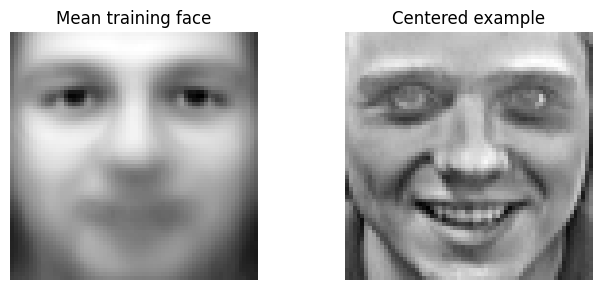

In [34]:

mean_face = X_train.mean(axis=0)
X_train_centered = X_train - mean_face
X_test_centered = X_test - mean_face
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].imshow(mean_face.reshape(height, width), cmap='gray'); ax[0].set_title('Mean training face')
ax[1].imshow(X_train_centered[0].reshape(height, width), cmap='gray'); ax[1].set_title('Centered example')
for a in ax: a.axis('off')
plt.tight_layout()

PCA basis shape (components x pixels): (299, 4096)
Reduced training matrix: (300, 299)
Reduced test matrix: (100, 299)
Variance retained: 100.0%
First 10 eigenvalues: [18.373  10.4587  6.6236  3.9735  2.9979  2.3593  1.8888  1.6495  1.6193
  1.4364]


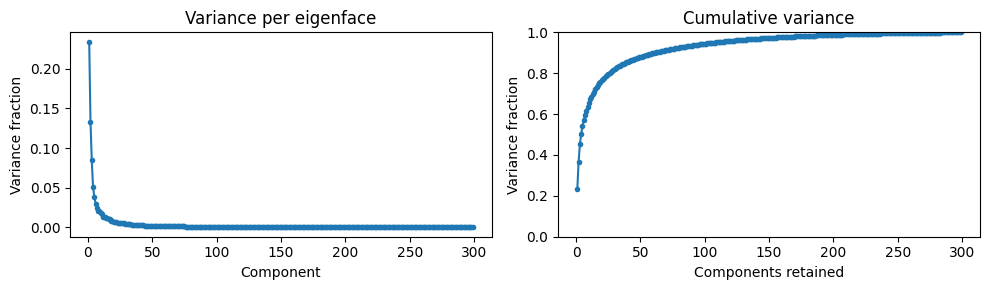

In [35]:
if not 1 <= N_COMPONENTS <= min(X_train_centered.shape):
    raise ValueError('N_COMPONENTS exceeds the available training dimensions')
pca = PCA(n_components=N_COMPONENTS, svd_solver='randomized', random_state=RANDOM_STATE)
Z_train = pca.fit_transform(X_train_centered)
Z_test = pca.transform(X_test_centered)
eigenvalues = pca.explained_variance_
ratios = pca.explained_variance_ratio_
print('PCA basis shape (components x pixels):', pca.components_.shape)
print('Reduced training matrix:', Z_train.shape)
print('Reduced test matrix:', Z_test.shape)
print(f'Variance retained: {ratios.sum():.1%}')
print('First 10 eigenvalues:', np.round(eigenvalues[:10], 4))
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(np.arange(1, len(ratios)+1), ratios, '.-'); ax[0].set(title='Variance per eigenface', xlabel='Component', ylabel='Variance fraction')
ax[1].plot(np.arange(1, len(ratios)+1), np.cumsum(ratios), '.-'); ax[1].set(title='Cumulative variance', xlabel='Components retained', ylabel='Variance fraction', ylim=(0,1))
plt.tight_layout()

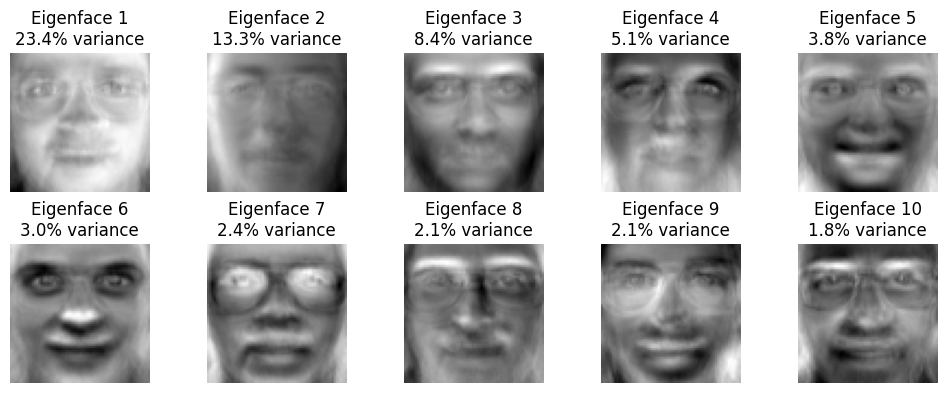

In [36]:

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, a in enumerate(axes.flat):
    a.imshow(pca.components_[i].reshape(height, width), cmap='gray')
    a.set_title(f'Eigenface {i+1}\n{ratios[i]:.1%} variance')
    a.axis('off')
plt.tight_layout()

Pixel reconstruction RMSE: 0.0245


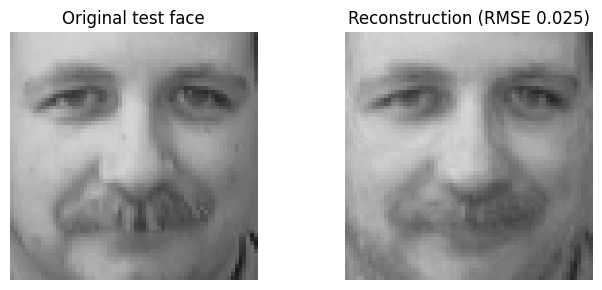

In [37]:

X_reconstructed = pca.inverse_transform(Z_test) + mean_face
j = 0
rmse = np.sqrt(np.mean((X_test[j] - X_reconstructed[j]) ** 2))
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].imshow(X_test[j].reshape(height,width), cmap='gray', vmin=0, vmax=1); ax[0].set_title('Original test face')
ax[1].imshow(np.clip(X_reconstructed[j].reshape(height,width),0,1), cmap='gray', vmin=0, vmax=1); ax[1].set_title(f'Reconstruction (RMSE {rmse:.3f})')
for a in ax: a.axis('off')
plt.tight_layout()
print(f'Pixel reconstruction RMSE: {rmse:.4f}')

Test accuracy with 299 eigenfaces: 94.0%
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       0.67      0.67      0.67         3
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       0.75      1.00      0.86         3
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1

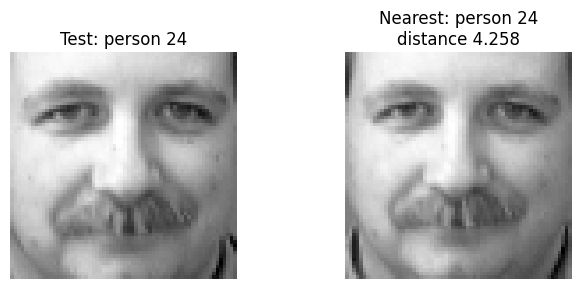

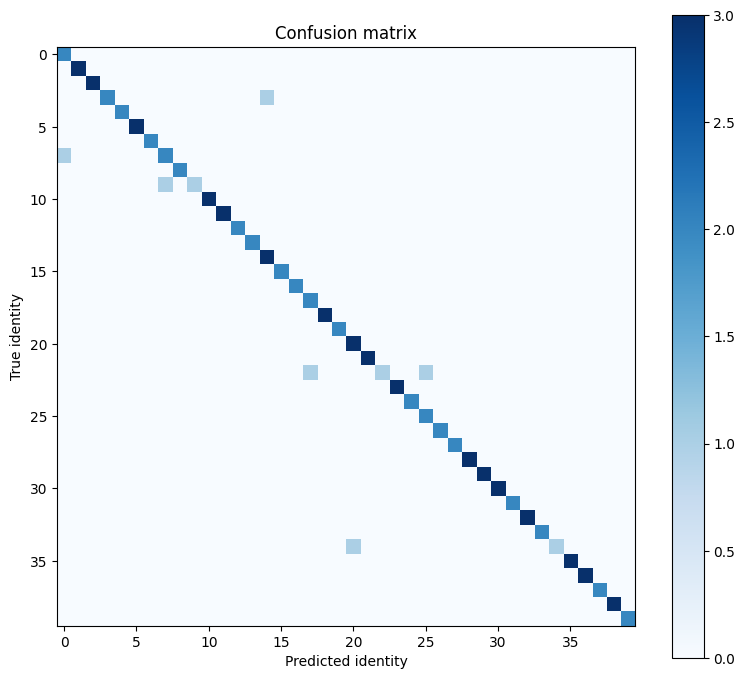

In [38]:
model = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
model.fit(Z_train, y_train)
predicted = model.predict(Z_test)
print(f'Test accuracy with {N_COMPONENTS} eigenfaces: {accuracy_score(y_test, predicted):.1%}')
print(classification_report(y_test, predicted, zero_division=0))

# Show a test face and its nearest training face.
dist = np.linalg.norm(Z_train - Z_test[j], axis=1)
nearest = np.argmin(dist)
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].imshow(img_test[j], cmap='gray'); ax[0].set_title(f'Test: person {y_test[j]}')
ax[1].imshow(img_train[nearest], cmap='gray'); ax[1].set_title(f'Nearest: person {y_train[nearest]}\ndistance {dist[nearest]:.3f}')
for a in ax: a.axis('off')
plt.tight_layout()
plt.figure(figsize=(8,7)); plt.imshow(confusion_matrix(y_test, predicted), cmap='Blues'); plt.colorbar()
plt.title('Confusion matrix'); plt.xlabel('Predicted identity'); plt.ylabel('True identity'); plt.tight_layout()